<a href="https://colab.research.google.com/github/Alk207-lab/-Machine-learning-projects-Sem1/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌸 **Experiment No 3**: Iris Flower Classification
Introduction

Iris Flower Classification is a supervised machine learning experiment in which the species of an iris flower is predicted from its flower measurements. In this experiment, the petal length and petal width are used as input features, while Iris-setosa, Iris-versicolor, and Iris-virginica are the target classes.

The dataset is first cleaned and preprocessed, followed by splitting it into training and testing sets. Different classification algorithms are then trained and evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

🎯 **Objective**

To build, compare, and evaluate different machine learning classification models for predicting the species of an iris flower and use the best-performing model to predict new flower values.

```text
┌──────────────────────┐
│   Start Experiment   │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│    Load Iris Data    │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│ Basic Preprocessing  │
│ • Remove empty cols  │
│ • Handle missing     │
│ • Remove duplicates  │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│   Select Features    │
│ • Petal Length       │
│ • Petal Width        │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│    Encode Target     │
│ • Setosa             │
│ • Versicolor         │
│ • Virginica          │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│   Train-Test Split   │
│ • 80% Training       │
│ • 20% Testing        │
└──────────┬───────────┘
           ↓
┌──────────────────┼──────────────────┐
│                  │                  │
↓                  ↓                  ↓
Logistic           KNN                SVM
Regression         Decision Tree      Random Forest
                                      Neural Network
└──────────────────┼──────────────────┘
                   ↓
┌──────────────────────┐
│   Model Evaluation   │
│ • Accuracy           │
│ • Precision          │
│ • Recall             │
│ • F1-Score           │
│ • Confusion Matrix   │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│  Compare All Models  │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│  Select Best Model   │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│ Predict New Flower   │
└──────────┬───────────┘
           ↓
┌──────────────────────┐
│         END          │
└──────────────────────┘
```

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [15]:
# ============================================================
# COMMON STEPS — RUN THIS FIRST
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from google.colab import files # Not needed since file is already present

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Set the correct file path as the file is already uploaded to /content/
file_path = "/content/IRIS (1).csv"

# Removed the files.upload() block as the file already exists.

# Load dataset using pd.read_csv as it's a CSV file
df = pd.read_csv(file_path)

# Basic preprocessing
df = df.dropna(axis=1, how="all").copy()
df.columns = [str(col).strip().lower() for col in df.columns]

df["species"] = df["species"].astype(str).str.strip()

features = ["petal_length", "petal_width"]
target = "species"

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=features + [target]).copy()
df = df.drop_duplicates().reset_index(drop=True)

# X and y
X = df[features]
y_text = df[target]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

# Same train-test split for every model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset Shape:", df.shape)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Classes:", list(label_encoder.classes_))

Dataset Shape: (147, 5)
Training Samples: 117
Testing Samples: 30
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


========== LOGISTIC REGRESSION ==========
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-Score : 0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



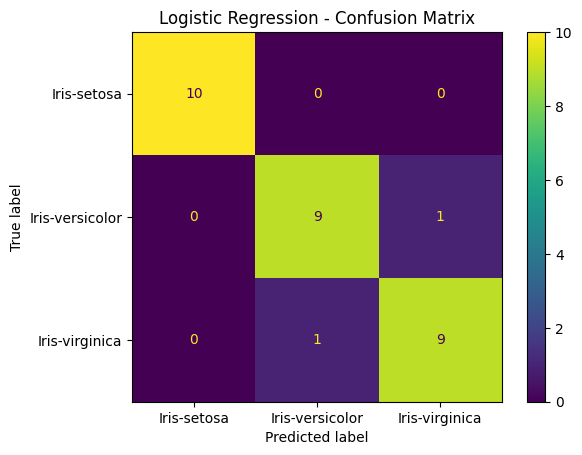

In [16]:
# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(
    y_test, y_pred_lr, average="weighted", zero_division=0
)
lr_recall = recall_score(
    y_test, y_pred_lr, average="weighted", zero_division=0
)
lr_f1 = f1_score(
    y_test, y_pred_lr, average="weighted", zero_division=0
)

print("========== LOGISTIC REGRESSION ==========")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_lr = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

========== KNN ==========
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1-Score : 0.9665831244778613

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



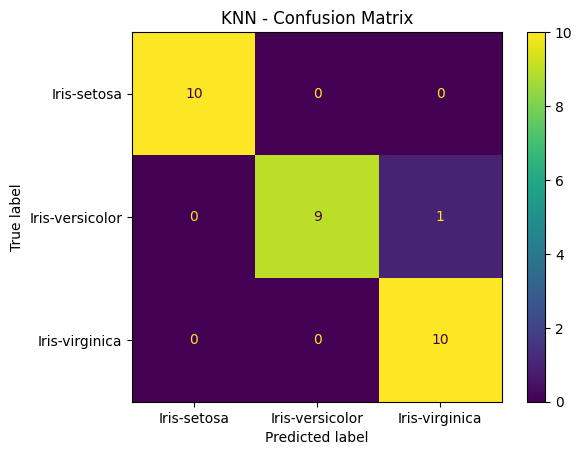

In [17]:
# ============================================================
# 2. K-NEAREST NEIGHBORS (KNN)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(
    y_test, y_pred_knn, average="weighted", zero_division=0
)
knn_recall = recall_score(
    y_test, y_pred_knn, average="weighted", zero_division=0
)
knn_f1 = f1_score(
    y_test, y_pred_knn, average="weighted", zero_division=0
)

print("========== KNN ==========")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-Score :", knn_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=label_encoder.classes_
).plot()

plt.title("KNN - Confusion Matrix")
plt.show()

========== SVM ==========
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-Score : 0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



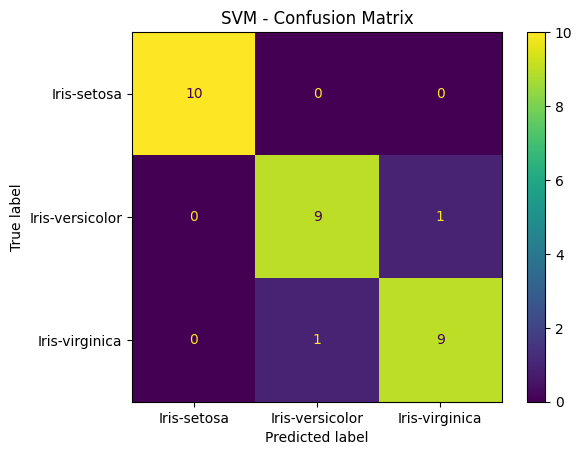

In [18]:
# ============================================================
# 3. SUPPORT VECTOR MACHINE (SVM)
# ============================================================

from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm, average="weighted", zero_division=0
)
svm_recall = recall_score(
    y_test, y_pred_svm, average="weighted", zero_division=0
)
svm_f1 = f1_score(
    y_test, y_pred_svm, average="weighted", zero_division=0
)

print("========== SVM ==========")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-Score :", svm_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_svm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=label_encoder.classes_
).plot()

plt.title("SVM - Confusion Matrix")
plt.show()

========== DECISION TREE ==========
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-Score : 0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



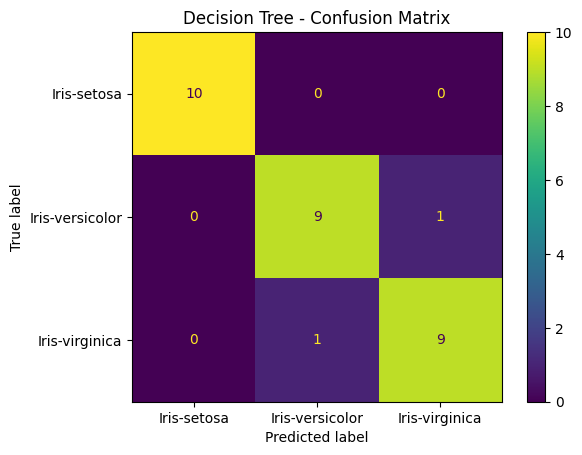

In [19]:
# ============================================================
# 4. DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)
dt_recall = recall_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)
dt_f1 = f1_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)

print("========== DECISION TREE ==========")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_dt = confusion_matrix(y_test, y_pred_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=label_encoder.classes_
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

========== RANDOM FOREST ==========
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1-Score : 0.9665831244778613

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



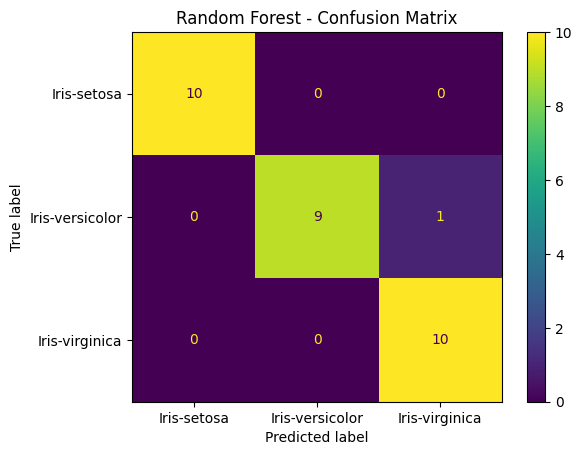

In [20]:
# ============================================================
# 5. RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)

print("========== RANDOM FOREST ==========")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

========== NEURAL NETWORK ==========
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1-Score : 0.9665831244778613

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



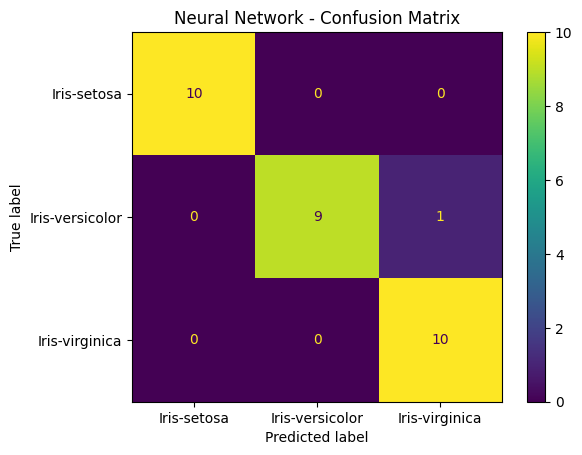

In [21]:
# ============================================================
# 6. NEURAL NETWORK
# ============================================================

from sklearn.neural_network import MLPClassifier

neural_network_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(10, 10),
        max_iter=2000,
        random_state=42
    ))
])

neural_network_model.fit(X_train, y_train)

y_pred_nn = neural_network_model.predict(X_test)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(
    y_test, y_pred_nn, average="weighted", zero_division=0
)
nn_recall = recall_score(
    y_test, y_pred_nn, average="weighted", zero_division=0
)
nn_f1 = f1_score(
    y_test, y_pred_nn, average="weighted", zero_division=0
)

print("========== NEURAL NETWORK ==========")
print("Accuracy :", nn_accuracy)
print("Precision:", nn_precision)
print("Recall   :", nn_recall)
print("F1-Score :", nn_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nn,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm_nn = confusion_matrix(y_test, y_pred_nn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=label_encoder.classes_
).plot()

plt.title("Neural Network - Confusion Matrix")
plt.show()

In [22]:
# ============================================================
# 7. COMPARE ALL MODELS
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        svm_accuracy,
        dt_accuracy,
        rf_accuracy,
        nn_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        svm_precision,
        dt_precision,
        rf_precision,
        nn_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        svm_recall,
        dt_recall,
        rf_recall,
        nn_recall
    ],
    "F1-Score": [
        lr_f1,
        knn_f1,
        svm_f1,
        dt_f1,
        rf_f1,
        nn_f1
    ]
})

results = results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("========== MODEL COMPARISON ==========")
display(results)

print("\nBEST MODEL:")
print(results.iloc[0])

========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.966667,0.969697,0.966667,0.966583
1,Neural Network,0.966667,0.969697,0.966667,0.966583
2,Random Forest,0.966667,0.969697,0.966667,0.966583
3,Logistic Regression,0.933333,0.933333,0.933333,0.933333
4,Decision Tree,0.933333,0.933333,0.933333,0.933333
5,SVM,0.933333,0.933333,0.933333,0.933333



BEST MODEL:
Model             KNN
Accuracy     0.966667
Precision    0.969697
Recall       0.966667
F1-Score     0.966583
Name: 0, dtype: object


Best Model: KNN
Best F1-Score: 0.9665831244778613
Best Accuracy: 0.9666666666666667

========== BEST MODEL CONFUSION MATRIX ==========


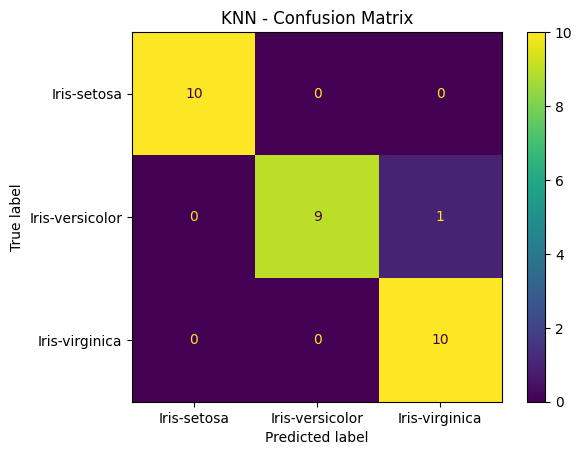


========== BEST MODEL CLASSIFICATION REPORT ==========
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [23]:
# ============================================================
# 8. SELECT BEST MODEL AUTOMATICALLY
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Neural Network": neural_network_model
}

best_model_name = results.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1-Score:", results.iloc[0]["F1-Score"])
print("Best Accuracy:", results.iloc[0]["Accuracy"])

best_predictions = best_model.predict(X_test)

print("\n========== BEST MODEL CONFUSION MATRIX ==========")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_predictions),
    display_labels=label_encoder.classes_
).plot()

plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

print("\n========== BEST MODEL CLASSIFICATION REPORT ==========")

print(classification_report(
    y_test,
    best_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
))

In [24]:
# ============================================================
# 9. PREDICT NEW VALUES USING THE BEST MODEL
# ============================================================

new_flower = pd.DataFrame({
    "petal_length": [4.5],
    "petal_width": [1.5]
})

predicted_class = best_model.predict(new_flower)[0]

predicted_species = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("========== NEW FLOWER PREDICTION ==========")
print("New Flower:")
display(new_flower)

print("Best Model:", best_model_name)
print("Predicted Species:", predicted_species)

========== NEW FLOWER PREDICTION ==========
New Flower:


,petal_length,petal_width
0,4.5,1.5


Best Model: KNN
Predicted Species: Iris-versicolor


In [25]:
# ============================================================
# 10. PREDICT MULTIPLE NEW VALUES
# ============================================================

new_flowers = pd.DataFrame({
    "petal_length": [1.5, 4.5, 5.5],
    "petal_width": [0.2, 1.5, 2.0]
})

predicted_classes = best_model.predict(new_flowers)

predicted_species = label_encoder.inverse_transform(
    predicted_classes
)

prediction_output = new_flowers.copy()
prediction_output["Predicted Species"] = predicted_species

print("========== FINAL PREDICTIONS ==========")
display(prediction_output)

========== FINAL PREDICTIONS ==========


,petal_length,petal_width,Predicted Species
0,1.5,0.2,Iris-setosa
1,4.5,1.5,Iris-versicolor
2,5.5,2.0,Iris-virginica


In [26]:
# ============================================================
# 11. FINAL PERFORMANCE TABLE
# ============================================================

final_results = results.copy()

final_results["Accuracy"] = (
    final_results["Accuracy"] * 100
).round(2)

final_results["Precision"] = (
    final_results["Precision"] * 100
).round(2)

final_results["Recall"] = (
    final_results["Recall"] * 100
).round(2)

final_results["F1-Score"] = (
    final_results["F1-Score"] * 100
).round(2)

print("========== FINAL MODEL PERFORMANCE (%) ==========")
display(final_results)

print("==============================================")
print("BEST MODEL :", best_model_name)
print("==============================================")

========== FINAL MODEL PERFORMANCE (%) ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,96.67,96.97,96.67,96.66
1,Neural Network,96.67,96.97,96.67,96.66
2,Random Forest,96.67,96.97,96.67,96.66
3,Logistic Regression,93.33,93.33,93.33,93.33
4,Decision Tree,93.33,93.33,93.33,93.33
5,SVM,93.33,93.33,93.33,93.33


BEST MODEL : KNN


### 📈 Decision Boundary

> **"The decision boundary shows how the trained model separates the three Iris species based on petal length and petal width."**

**Figure:** Decision boundary showing the classification regions of the trained model.

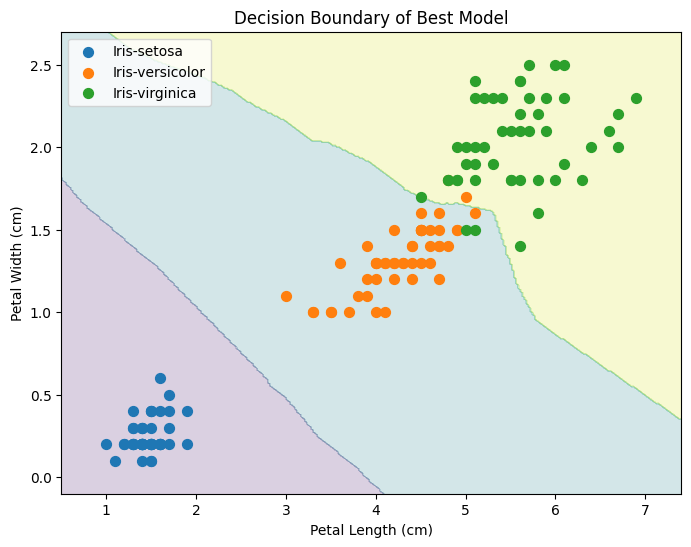

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# DECISION BOUNDARY OF BEST MODEL
# ==========================================

# Create a grid
x1 = np.linspace(X["petal_length"].min() - 0.5,
                 X["petal_length"].max() + 0.5, 300)

x2 = np.linspace(X["petal_width"].min() - 0.2,
                 X["petal_width"].max() + 0.2, 300)

xx, yy = np.meshgrid(x1, x2)

# Convert grid into DataFrame
grid = pd.DataFrame({
    "petal_length": xx.ravel(),
    "petal_width": yy.ravel()
})

# Predict grid points using best model
Z = best_model.predict(grid)

# Reshape predictions
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.2)

# Plot actual data
for i, species in enumerate(label_encoder.classes_):

    data = df[df["species"] == species]

    plt.scatter(
        data["petal_length"],
        data["petal_width"],
        label=species,
        s=50
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Boundary of Best Model")

plt.legend()
plt.show()

### Conclusion

The experiment successfully demonstrates the use of machine learning for **Iris flower classification**. The dataset is preprocessed and the petal length and petal width are selected as input features, while the flower species is used as the target. Six classification algorithms—**Logistic Regression, KNN, SVM, Decision Tree, Random Forest, and Neural Network**—are trained and tested. Their performance is evaluated using **accuracy, precision, recall, F1-score, and confusion matrix**. The results of all models are compared to identify the best-performing model. Finally, the selected best model is used to predict the species of new Iris flowers based on their petal measurements.
